# Problema 2 - Corrección de multiple choice

Corrección automática de exámenes multiple choice de 10 preguntas (opciones A, B, C, D)
tomando como única entrada la imagen de cada examen.

Respuestas correctas: **1.C 2.B 3.A 4.D 5.B 6.B 7.A 8.B 9.D 10.D**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Punto a - Corrección de las respuestas (OK/MAL)

Se detectan las celdas de cada pregunta a partir de las líneas verticales y
horizontales (sumando los píxeles por fila y por columna), se aísla la respuesta
marcada en cada una y se identifica la opción elegida. Luego se compara con las
respuestas correctas mostrando `OK` o `MAL` por pregunta.

In [2]:
def agrupar_indices(indices):
    """Agrupa índices consecutivos en intervalos."""

    grupos = []

    if len(indices) == 0:
        return grupos

    inicio = indices[0]
    anterior = indices[0]

    for indice in indices[1:]:
        if indice == anterior + 1:
            anterior = indice
        else:
            grupos.append((inicio, anterior))
            inicio = indice
            anterior = indice

    grupos.append((inicio, anterior))

    return grupos

In [3]:
def obtener_cuadrantes(img, grupos_x, grupos_y):

    cuadrantes = []

    for fila in range(5):
        for columna in range(2):

            if columna == 0:
                x_inicio = grupos_x[0][1] + 3
                x_fin = grupos_x[1][0] - 3
            else:
                x_inicio = grupos_x[2][1] + 3
                x_fin = grupos_x[3][0] - 3

            y_inicio = grupos_y[fila][1] + 3
            y_fin = grupos_y[fila + 1][0] - 3

            cuadrante = img[
                y_inicio:y_fin,
                x_inicio:x_fin
            ]

            cuadrantes.append(cuadrante)

    return cuadrantes

In [4]:
def recortar_respuesta(respuesta):

    _, binaria = cv2.threshold(
        respuesta,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Filas que contienen al menos un píxel negro
    filas_con_negro = np.any(
        binaria == 0,
        axis=1
    )

    # Columnas que contienen al menos un píxel negro
    columnas_con_negro = np.any(
        binaria == 0,
        axis=0
    )

    # Límites verticales
    indices_filas = np.where(filas_con_negro)[0]

    # Límites horizontales
    indices_columnas = np.where(columnas_con_negro)[0]

    if (
        len(indices_filas) == 0
        or len(indices_columnas) == 0
    ):
        return None

    y_inicio = indices_filas[0]
    y_fin = indices_filas[-1]

    x_inicio = indices_columnas[0]
    x_fin = indices_columnas[-1]

    # Recorte final
    respuesta_recortada = respuesta[
        y_inicio:y_fin + 1,
        x_inicio:x_fin + 1
    ]

    return respuesta_recortada

In [5]:
def obtener_respuesta(cuadrante):

    # Binarización
    _, binaria = cv2.threshold(
        cuadrante,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Kernel horizontal
    kernel = np.array([
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  2,  2,  2,  2,  2,  2,  2],
        [-1, -1, -1, -1, -1, -1, -1, -1]
    ])

    # Filtrado
    filtrada = cv2.filter2D(
        binaria,
        cv2.CV_64F,
        kernel
    )

    filtrada_abs = np.abs(filtrada)

    # Detección de la línea
    deteccion = (
        filtrada_abs >= filtrada_abs.max() * 0.9
    )

    # Coordenada Y de la línea
    conteo_y = np.sum(
        deteccion,
        axis=1
    )

    y_linea = np.argmax(conteo_y)

    # Extremos X de la línea
    xs_linea = np.where(
        deteccion[y_linea]
    )[0]

    x_inicio_linea = xs_linea.min()
    x_fin_linea = xs_linea.max()

    # Región superior a la línea
    region_opciones = cuadrante[
        0:y_linea,
        x_inicio_linea:x_fin_linea
    ]

    # Binarización
    _, binaria_opciones = cv2.threshold(
        region_opciones,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Verificar si existe una respuesta
    ultimas_filas = binaria_opciones[-14:, :]

    hay_pixel_negro = np.any(
        ultimas_filas == 0
    )

    if not hay_pixel_negro:
        return None

    # Detectar filas con píxeles negros
    proyeccion_y = np.any(
        binaria_opciones == 0,
        axis=1
    )

    indices_negros = np.where(
        proyeccion_y
    )[0]

    grupos_renglones = agrupar_indices(
        indices_negros
    )

    if len(grupos_renglones) == 0:
        return None

    # Último renglón = respuesta
    y_inicio, y_fin = grupos_renglones[-1]

    respuesta = region_opciones[
        y_inicio:y_fin + 1,
        :
    ]

    respuesta = recortar_respuesta(respuesta)

    return respuesta

In [6]:
def procesar_examen(ruta_imagen):

    img = cv2.imread(
        ruta_imagen,
        cv2.IMREAD_GRAYSCALE
    )

    # Binarización
    _, binary = cv2.threshold(
        img,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Proyecciones
    proyeccion_x = np.sum(
        binary == 0,
        axis=0
    )

    proyeccion_y = np.sum(
        binary == 0,
        axis=1
    )

    # Detección de líneas
    lineas_x = np.where(
        proyeccion_x >= 200
    )[0]

    lineas_y = np.where(
        proyeccion_y >= 200
    )[0]

    grupos_x = agrupar_indices(lineas_x)
    grupos_y = agrupar_indices(lineas_y)

    # Extracción de cuadrantes
    cuadrantes = obtener_cuadrantes(
        img,
        grupos_x,
        grupos_y[1:]
    )

    # Detección de respuestas
    respuestas = []

    for cuadrante in cuadrantes:
        respuesta = obtener_respuesta(cuadrante)
        respuestas.append(respuesta)

    # Reordenar según la numeración real de las preguntas
    respuestas = [
        respuestas[0],  # Pregunta 1
        respuestas[2],  # Pregunta 2
        respuestas[4],  # Pregunta 3
        respuestas[6],  # Pregunta 4
        respuestas[8],  # Pregunta 5
        respuestas[1],  # Pregunta 6
        respuestas[3],  # Pregunta 7
        respuestas[5],  # Pregunta 8
        respuestas[7],  # Pregunta 9
        respuestas[9]   # Pregunta 10
    ]

    return img, cuadrantes, respuestas

In [7]:
def obtener_descriptor(respuesta):
    _, binaria = cv2.threshold(
        respuesta,
        200,
        255,
        cv2.THRESH_BINARY
    )

    return np.sum(
        binaria == 0,
        axis=1
    )


def crear_referencias(examen, indices_letras):
    referencias = {}

    for indice, letra in indices_letras.items():
        respuesta = examen['respuestas'][indice]
        referencias[letra] = obtener_descriptor(respuesta)

    return referencias


def identificar_respuesta(respuesta, referencias, umbral=50):

    if respuesta is None:
        return "No válido"

    descriptor = obtener_descriptor(respuesta)

    distancias = {}

    for letra, referencia in referencias.items():
        distancias[letra] = np.linalg.norm(
            descriptor - referencia
        )

    letra_mas_cercana = min(
        distancias,
        key=distancias.get
    )

    distancia_minima = distancias[letra_mas_cercana]

    if distancia_minima > umbral:
        return "No válido"

    return letra_mas_cercana

In [8]:
RESPUESTAS_CORRECTAS = [
    'C', 'B', 'A', 'D', 'B',
    'B', 'A', 'B', 'D', 'D'
]


def corregir_examen(ruta_imagen, referencias, umbral=50):

    # Procesar examen
    img, cuadrantes, respuestas = procesar_examen(ruta_imagen)

    # Identificar letras
    letras = []

    for respuesta in respuestas:

        letra = identificar_respuesta(
            respuesta,
            referencias,
            umbral
        )

        letras.append(letra)

    # Mostrar resultados
    for i, (respuesta, correcta) in enumerate(
        zip(letras, RESPUESTAS_CORRECTAS),
        start=1
    ):

        if respuesta == correcta:
            resultado = "OK"
        else:
            resultado = "MAL"

        print(
            f"Pregunta {i}: {resultado}"
        )

    return letras

In [9]:
def plotear_respuestas(respuestas):

    fig, axs = plt.subplots(
        5,
        2,
        figsize=(10, 10)
    )

    for i, respuesta in enumerate(respuestas):

        ax = axs[i // 2, i % 2]

        if respuesta is not None:
            ax.imshow(
                respuesta,
                cmap='gray',
                vmin=0,
                vmax=255
            )
            ax.set_title(f'Pregunta {i + 1}')
        else:
            ax.set_title(f'Pregunta {i + 1} - Sin respuesta')

        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Punto b - Validación de los datos del encabezado

Se reutiliza la técnica del punto a (proyecciones y componentes conectadas) para
aislar el encabezado. Las tres líneas horizontales (Name, Date y Class) se detectan
como las componentes conectadas con mayor relación ancho/alto (líneas finas y largas).

Para validar cada campo **no se reconoce el texto**, solo se cuentan cantidades:
segmentando por columnas, cada corrida de columnas con tinta es un carácter, y una
separación (gap) mayor a medio alto del texto indica un cambio de palabra.

Restricciones:
- **Name:** al menos dos palabras y no más de 25 caracteres.
- **Date:** 8 caracteres formando una sola palabra.
- **Class:** un único carácter.

In [ ]:
def detectar_lineas_encabezado(img, ancho_minimo=40, umbral_ratio=15):
    """Detecta las 3 líneas horizontales del encabezado (Name, Date, Class).

    Se queda con las componentes conectadas de mayor relación ancho/alto
    (líneas finas y largas), ordenadas de izquierda a derecha.
    """
    # El subrayado del encabezado es la primera línea horizontal larga
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    proyeccion_y = np.sum(binary == 0, axis=1)
    y_subrayado = np.where(proyeccion_y >= 200)[0][0]

    encabezado = img[0:y_subrayado + 3, :]

    # Componentes conectadas (texto y líneas en blanco sobre fondo negro)
    _, binaria_inv = cv2.threshold(
        encabezado, 127, 255, cv2.THRESH_BINARY_INV
    )
    n, _, stats, _ = cv2.connectedComponentsWithStats(
        binaria_inv, 8, cv2.CV_32S
    )

    lineas = []
    for i in range(1, n):
        x, y, w, h, _ = stats[i]
        if w > ancho_minimo and w / max(h, 1) > umbral_ratio:
            lineas.append((x, y, w, h))

    lineas.sort(key=lambda linea: linea[0])

    return lineas

In [ ]:
def segmentar_caracteres(region):
    """Devuelve los intervalos (x_inicio, x_fin) de cada carácter.

    Se usa la proyección por columnas: cada corrida de columnas con tinta
    corresponde a un carácter. Es más robusto que las componentes conectadas
    (una letra partida o una barra "/" fragmentada siguen siendo una sola
    corrida de columnas).
    """
    tinta = region < 128
    columnas_con_tinta = tinta.any(axis=0)

    caracteres = []
    inicio = None

    for x, tiene_tinta in enumerate(columnas_con_tinta):
        if tiene_tinta and inicio is None:
            inicio = x
        elif not tiene_tinta and inicio is not None:
            caracteres.append((inicio, x - 1))
            inicio = None

    if inicio is not None:
        caracteres.append((inicio, len(columnas_con_tinta) - 1))

    return caracteres

In [ ]:
def analizar_campo(img, linea):
    """Recorta el texto de un campo (arriba de su línea, dentro de su rango x)
    y cuenta la cantidad de caracteres y de palabras.
    """
    x, y, w, h = linea

    # Región del texto: por encima de la línea y dentro de su ancho
    region = img[0:y - 1, x:x + w]

    caracteres = segmentar_caracteres(region)
    cantidad_caracteres = len(caracteres)
    if cantidad_caracteres == 0:
        return 0, 0

    # Palabras: un gap mayor a umbral_gap (en píxeles) separa dos palabras
    umbral_gap = 5
    cantidad_palabras = 1

    for actual, siguiente in zip(caracteres, caracteres[1:]):
        gap = siguiente[0] - actual[1] - 1
        if gap > umbral_gap:
            cantidad_palabras += 1

    return cantidad_caracteres, cantidad_palabras

In [ ]:
def validar_encabezado(ruta_imagen):
    """Valida los campos Name, Date y Class de un examen e imprime su estado."""
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

    lineas = detectar_lineas_encabezado(img)
    nombres = ['Name', 'Date', 'Class']

    conteos = {}
    for linea, nombre in zip(lineas, nombres):
        conteos[nombre] = analizar_campo(img, linea)

    # Name: al menos dos palabras y no más de 25 caracteres
    n_caracteres, n_palabras = conteos['Name']
    name_ok = (n_palabras >= 2) and (1 <= n_caracteres <= 25)

    # Date: 8 caracteres formando una sola palabra
    d_caracteres, d_palabras = conteos['Date']
    date_ok = (d_caracteres == 8) and (d_palabras == 1)

    # Class: un único carácter
    c_caracteres, _ = conteos['Class']
    class_ok = (c_caracteres == 1)

    print(f"Name: {'OK' if name_ok else 'MAL'}")
    print(f"Date: {'OK' if date_ok else 'MAL'}")
    print(f"Class: {'OK' if class_ok else 'MAL'}")

    return {'Name': name_ok, 'Date': date_ok, 'Class': class_ok}

In [ ]:
for numero_examen in range(1, 6):

    print(f"Exámen {numero_examen}:")

    ruta = f'../images/raw/examen_{numero_examen}.png'
    validar_encabezado(ruta)

    print()

## Punto c - Evaluación de los exámenes resueltos

Se aplica el algoritmo del punto a sobre las imágenes `examen_x.png` y se informan
los resultados de cada uno.

In [10]:
examenes = {}

for i in range(1, 6):

    ruta = f'../images/raw/examen_{i}.png'
    img, cuadrantes, respuestas = procesar_examen(ruta)

    examenes[i] = {
        'imagen': img,
        'cuadrantes': cuadrantes,
        'respuestas': respuestas
    }

indices_letras = {0: 'B', 5: 'A', 1: 'C', 2: 'D'}

referencias = crear_referencias(examenes[4], indices_letras)


for numero_examen in range(1, 6):

    print(f"Exámen {numero_examen}:")

    ruta = f'../images/raw/examen_{numero_examen}.png'
    corregir_examen(ruta, referencias)

    print()

Exámen 1:
Pregunta 1: MAL
Pregunta 2: MAL
Pregunta 3: MAL
Pregunta 4: MAL
Pregunta 5: MAL
Pregunta 6: MAL
Pregunta 7: MAL
Pregunta 8: MAL
Pregunta 9: MAL
Pregunta 10: MAL

Exámen 2:
Pregunta 1: MAL
Pregunta 2: OK
Pregunta 3: MAL
Pregunta 4: OK
Pregunta 5: MAL
Pregunta 6: OK
Pregunta 7: OK
Pregunta 8: MAL
Pregunta 9: MAL
Pregunta 10: OK

Exámen 3:
Pregunta 1: OK
Pregunta 2: OK
Pregunta 3: OK
Pregunta 4: OK
Pregunta 5: OK
Pregunta 6: OK
Pregunta 7: OK
Pregunta 8: OK
Pregunta 9: OK
Pregunta 10: OK

Exámen 4:
Pregunta 1: MAL
Pregunta 2: MAL
Pregunta 3: MAL
Pregunta 4: MAL
Pregunta 5: MAL
Pregunta 6: MAL
Pregunta 7: MAL
Pregunta 8: MAL
Pregunta 9: MAL
Pregunta 10: MAL

Exámen 5:
Pregunta 1: OK
Pregunta 2: OK
Pregunta 3: OK
Pregunta 4: OK
Pregunta 5: OK
Pregunta 6: OK
Pregunta 7: OK
Pregunta 8: OK
Pregunta 9: OK
Pregunta 10: OK



## Punto d - Imagen de salida con aprobados y desaprobados

Se genera una imagen que reúne los recortes (crop) del campo **Name** de todos los
exámenes del punto c. Un alumno aprueba con **al menos 6 respuestas correctas**.
Los aprobados se marcan en **verde** y los desaprobados en **rojo**.

In [16]:
def recortar_campo_nombre(img):
    """Recorta la sub-imagen del campo Name del encabezado.

    Reutiliza la detección de líneas del encabezado (punto b): la primera
    línea (la de más a la izquierda) corresponde al campo Name.
    """
    lineas = detectar_lineas_encabezado(img)
    x, y, w, h = lineas[0]
    return img[0:y - 1, x:x + w]


def contar_respuestas_correctas(letras):
    """Cuenta cuántas respuestas coinciden con las correctas."""
    return sum(
        1
        for letra, correcta in zip(letras, RESPUESTAS_CORRECTAS)
        if letra == correcta
    )

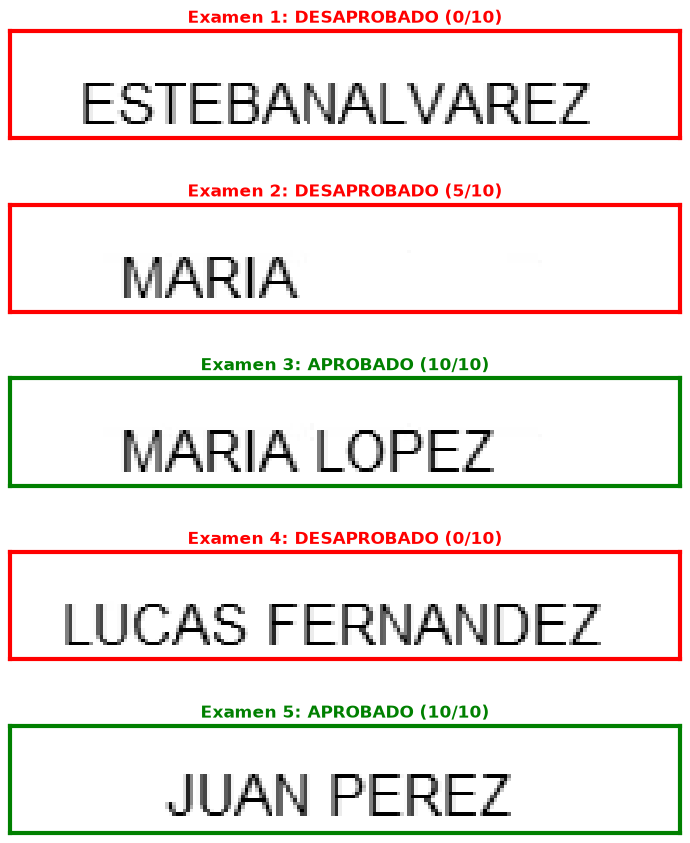

Imagen de salida guardada en: ../images/output/problema_2.png


In [17]:
UMBRAL_APROBADO = 6

def generar_imagen_resultados(ruta_salida='../images/output/problema_2.png'):
    fig, axs = plt.subplots(5, 1, figsize=(7, 9))

    for idx, numero_examen in enumerate(range(1, 6)):

        ruta = f'../images/raw/examen_{numero_examen}.png'
        img, cuadrantes, respuestas = procesar_examen(ruta)

        # Corrección (punto a) para contar respuestas correctas
        letras = [
            identificar_respuesta(respuesta, referencias)
            for respuesta in respuestas
        ]
        correctas = contar_respuestas_correctas(letras)
        aprobado = correctas >= UMBRAL_APROBADO

        # Crop del campo Name
        crop_nombre = recortar_campo_nombre(img)

        # Verde si aprobó, rojo si no
        color = 'green' if aprobado else 'red'
        estado = 'APROBADO' if aprobado else 'DESAPROBADO'

        ax = axs[idx]
        ax.imshow(crop_nombre, cmap='gray', vmin=0, vmax=255)
        ax.set_title(
            f'Examen {numero_examen}: {estado} ({correctas}/10)',
            color=color,
            fontsize=12,
            fontweight='bold'
        )
        ax.set_xticks([])
        ax.set_yticks([])

        # Borde de color alrededor del crop
        for spine in ax.spines.values():
            spine.set_color(color)
            spine.set_linewidth(3)

    plt.tight_layout()
    plt.savefig(ruta_salida, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Imagen de salida guardada en: {ruta_salida}')


generar_imagen_resultados()